# V3 empirical study — 1.5-year monthly calibration — return-based models

**This notebook is the computational source of truth.** The PDF in this folder is written from the same `payload` dict, so every table number matches.

| Item | Setting |
|------|---------|
| Models | MD-GBM, GBM, GARCH, Merton, GARCH–Merton |
| Companies | SPY (primary), AAPL, MSFT, AMZN |
| Regimes | Crisis 2008-08-01→2009-07-31 · Normal 2014-01-01→2014-12-31 · Late-cycle 2018-10-01→2019-09-30 · COVID 2019-09-01→2020-08-31 |
| Calibration | **1.5-year** lookback, **monthly** recalibration |
| Primary metric | Percentage RMSE |
| Secondary | MAE%, Bias% |
| Paths | LSM American calls, `n_paths=10000`, `seed=42` |
| Code | V3 notebooks + `option_filters.py` + Euler-corrected Heston step |

**MD-GBM** means Markov Directional Geometric Brownian Motion. Specification: `V4_MD-GBM_model.pdf` in this folder.

In every table the **BEST** model is the lowest RMSE%. That row is **bold and green**.


## 0. Methodology and conditions

### No look-ahead
At monthly update t, parameters use only returns and listed quotes with `trading_date ≤ t`. LSM prices a Monday contract with the latest calibration row dated on or before that Monday. Option quotes are as-of the grid timestamp (same session, else the prior session).

### Shared sample (no model-specific data selection)
For each company × regime the Monday nearest-ATM listed-call sample is drawn **once** and passed to all five models in this report. Filters, testing dates, simulation settings, and the market benchmark are therefore identical.

### Filters (applied in this order)
1. Calls only; finite S, K, C.
2. No-arbitrage: C ≥ max(0, S−K).
3. Maturity: 7 ≤ DTE ≤ 60.
4. Moneyness: |S/K − 1| ≤ 10%.
5. Liquidity: premium ≥ 0.05; valid bid–ask and relative spread ≤ 50% when those columns exist; volume ≥ 1 when present.

### Metrics
- Primary: RMSE%.
- Secondary: **MAE% = 100 × mean(|model − market|/market)**, **Bias% = 100 × mean((model − market)/market)**.
- Ranking uses RMSE% only. Bias% is the scale-free signed companion.

### Model-correctness adjustments
- Heston / Heston–Merton: option-implied Fourier NLS for (κ, θ, ξ, ρ, v0). Not Method A.
- Euler: stock return over [t, t+Δt] uses **current** v_t; then update v_{t+Δt}.
- LSM never averages paths before stopping.

### Data limits
Equity adj-close starts **2003-12-01**. Listed-option panels start **2008-01**. Estimators use all available history when the requested lookback is longer than the file.

### Re-run
This notebook is a grouped companion. It loads stored cells and does **not** re-run LSM. To rebuild only this group's PDF/notebook, call `groups.write_group(...)`. Do not set RECOMPUTE on the six-model engine; that would overwrite the original study files.


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML, Markdown, Image
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V4-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_1p5y_10k_monthly_empirical_study_groups as groups
payload = groups.load_group('return_based')
print('cells', len(payload['cells']), 'models', payload['meta']['models'])
# Rebuild this group's PDF/notebook only (does not overwrite the six-model study):
# groups.write_group('return_based')

## 1. Shared evaluation sample


In [1]:
from IPython.display import HTML, display
rows = ['<h4>n contracts (identical across models)</h4>']
display(HTML(''.join(study._html_table(payload['tables'][k]) if False else '')))
meta = payload['shared_contracts']
import pandas as pd
df = pd.DataFrame([{ 'regime': r, **meta[r]['n'], 'start': meta[r]['period_start'], 'end': meta[r]['period_end']} for r in study.REGIME_ORDER])
display(df)

Regime,Window,SPY,AAPL,MSFT,AMZN
2008-2009 Crisis,2008-08-01 → 2009-07-31,50,50,50,50
2013-2014 Normal,2014-01-01 → 2014-12-31,50,50,50,50
2018-2019 Late-cycle,2018-10-01 → 2019-09-30,50,51,50,51
2019-2020 COVID,2019-09-01 → 2020-08-31,50,50,50,50


## 2.1 Detailed tables — `SPY`


### Table SPY-1. SPY · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2008-2009'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,41.02,32.65,-4.71,1
GBM,55.01,40.97,+21.16,5
GARCH,43.04,35.72,+33.41,2
Merton,51.73,37.42,+25.72,4
GARCH–Merton,44.31,37.49,+36.30,3


### Table SPY-2. SPY · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2013-2014'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,29.99,24.17,+13.83,1
GBM,38.08,30.45,+24.88,5
GARCH,36.35,29.04,+22.86,2
Merton,37.32,29.83,+23.72,3
GARCH–Merton,37.90,30.58,+24.87,4


### Table SPY-3. SPY · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2018-2019'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,36.48,31.07,+14.03,1
GBM,49.51,41.57,+32.90,2
GARCH,65.98,49.13,+41.26,4
Merton,60.60,52.40,+46.39,3
GARCH–Merton,68.12,51.50,+44.06,5


### Table SPY-4. SPY · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2019-2020'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,43.63,36.23,+14.85,1
GBM,64.88,57.43,+44.13,4
GARCH,53.62,42.08,+35.24,3
Merton,70.92,64.09,+53.08,5
GARCH–Merton,52.76,41.90,+35.13,2


## 2.2 Detailed tables — Company summary


Same four-regime layout as SPY. Each value is the arithmetic mean of **AAPL, MSFT, AMZN**. Ranking uses mean RMSE%.


### Table Co-1. Company summary · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = GARCH** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2008-2009', study._equity_tickers()))))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,37.97,29.51,+5.30,2
GBM,49.54,37.95,+23.71,5
GARCH,37.65,31.10,+23.97,1
Merton,47.89,36.89,+30.25,4
GARCH–Merton,45.49,38.29,+35.63,3


### Table Co-2. Company summary · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = MD-GBM** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2013-2014', study._equity_tickers()))))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,30.15,24.58,+14.84,1
GBM,47.93,39.44,+36.05,3
GARCH,53.53,43.66,+39.14,4
Merton,46.87,37.36,+34.12,2
GARCH–Merton,75.13,64.41,+64.13,5


### Table Co-3. Company summary · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · mean of AAPL, MSFT, AMZN · n̄ = 51 · **BEST = MD-GBM** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2018-2019', study._equity_tickers()))))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,27.95,24.23,+7.20,1
GBM,39.31,33.51,+23.84,3
GARCH,36.84,29.16,+21.78,2
Merton,43.10,37.05,+32.25,4
GARCH–Merton,49.41,40.98,+37.98,5


### Table Co-4. Company summary · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · mean of AAPL, MSFT, AMZN · n̄ = 50 · **BEST = MD-GBM** (lowest mean RMSE%).


In [1]:
display(HTML(study._html_table(study._average_company_table(payload, '2019-2020', study._equity_tickers()))))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,34.58,27.59,+9.56,1
GBM,48.18,39.74,+30.10,3
GARCH,41.61,31.18,+23.29,2
Merton,52.19,44.42,+37.76,4
GARCH–Merton,52.64,41.77,+36.69,5


## 2.3 Detailed tables — `AAPL`


### Table AAPL-1. AAPL · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2008-2009'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,43.89,32.72,+12.84,3
GBM,57.67,42.83,+31.10,5
GARCH,34.36,28.77,+25.46,1
Merton,55.37,40.83,+36.40,4
GARCH–Merton,40.33,34.50,+32.14,2


### Table AAPL-2. AAPL · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2013-2014'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,30.36,23.26,+17.13,1
GBM,50.20,39.70,+38.63,4
GARCH,40.08,29.28,+23.86,2
Merton,48.87,38.01,+37.02,3
GARCH–Merton,59.86,50.37,+50.37,5


### Table AAPL-3. AAPL · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2018-2019'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,23.64,20.27,+5.37,1
GBM,32.53,28.14,+18.76,2
GARCH,40.82,29.83,+21.75,4
Merton,36.65,31.82,+28.29,3
GARCH–Merton,54.71,44.78,+41.77,5


### Table AAPL-4. AAPL · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2019-2020'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,31.97,25.38,+9.95,1
GBM,46.19,39.52,+30.76,3
GARCH,45.53,33.84,+29.35,2
Merton,47.03,40.14,+35.87,4
GARCH–Merton,57.26,46.26,+44.06,5


## 2.4 Detailed tables — `MSFT`


### Table MSFT-1. MSFT · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2008-2009'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,34.43,27.73,+3.32,1
GBM,44.02,34.76,+17.99,3
GARCH,50.93,41.05,+35.87,4
Merton,41.80,34.10,+23.08,2
GARCH–Merton,61.38,51.11,+48.59,5


### Table MSFT-2. MSFT · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2013-2014'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,38.79,31.25,+28.02,1
GBM,62.49,53.14,+52.98,3
GARCH,85.94,73.78,+73.69,4
Merton,56.13,47.20,+46.76,2
GARCH–Merton,108.47,97.36,+97.36,5


### Table MSFT-3. MSFT · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2018-2019'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,25.61,21.67,+4.03,1
GBM,41.73,34.38,+27.55,3
GARCH,37.25,30.23,+24.44,2
Merton,43.31,35.57,+33.24,4
GARCH–Merton,48.79,40.81,+38.95,5


### Table MSFT-4. MSFT · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2019-2020'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,31.75,23.91,+4.32,1
GBM,45.93,37.46,+28.12,2
GARCH,49.20,34.48,+25.36,3
Merton,50.06,41.56,+34.80,4
GARCH–Merton,54.17,40.27,+34.17,5


## 2.5 Detailed tables — `AMZN`


### Table AMZN-1. AMZN · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2008-2009'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,35.59,28.09,-0.26,3
GBM,46.92,36.28,+22.05,5
GARCH,27.67,23.47,+10.57,1
Merton,46.51,35.73,+31.26,4
GARCH–Merton,34.76,29.27,+26.15,2


### Table AMZN-2. AMZN · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = MD-GBM** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2013-2014'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,21.30,19.23,-0.63,1
GBM,31.09,25.49,+16.54,2
GARCH,34.57,27.93,+19.87,3
Merton,35.62,26.86,+18.58,4
GARCH–Merton,57.06,45.50,+44.68,5


### Table AMZN-3. AMZN · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2018-2019'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,34.59,30.76,+12.20,2
GBM,43.66,38.02,+25.21,3
GARCH,32.44,27.42,+19.15,1
Merton,49.34,43.76,+35.22,5
GARCH–Merton,44.74,37.34,+33.22,4


### Table AMZN-4. AMZN · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AMZN|2019-2020'])))

Model,RMSE%,MAE%,Bias%,Ranking
MD-GBM,40.03,33.48,+14.41,2
GBM,52.42,42.24,+31.41,4
GARCH,30.12,25.22,+15.17,1
Merton,59.46,51.55,+42.61,5
GARCH–Merton,46.47,38.78,+31.83,3


## 3. Summary tables


### Table S1 — Overall ranking


In [1]:
display(HTML('overall ranking table is rendered from payload["summary_overall"]'))

Rank,Model,Mean RMSE%,Median RMSE%,# cells best
1,MD-GBM BEST,33.94,34.51,12
2,GARCH,44.24,40.45,4
3,GBM,47.65,46.56,0
4,Merton,49.42,49.10,0
5,GARCH–Merton,54.44,53.47,0


## 4. Figures


### Figure 1 — RMSE% by regime (mean of four companies)


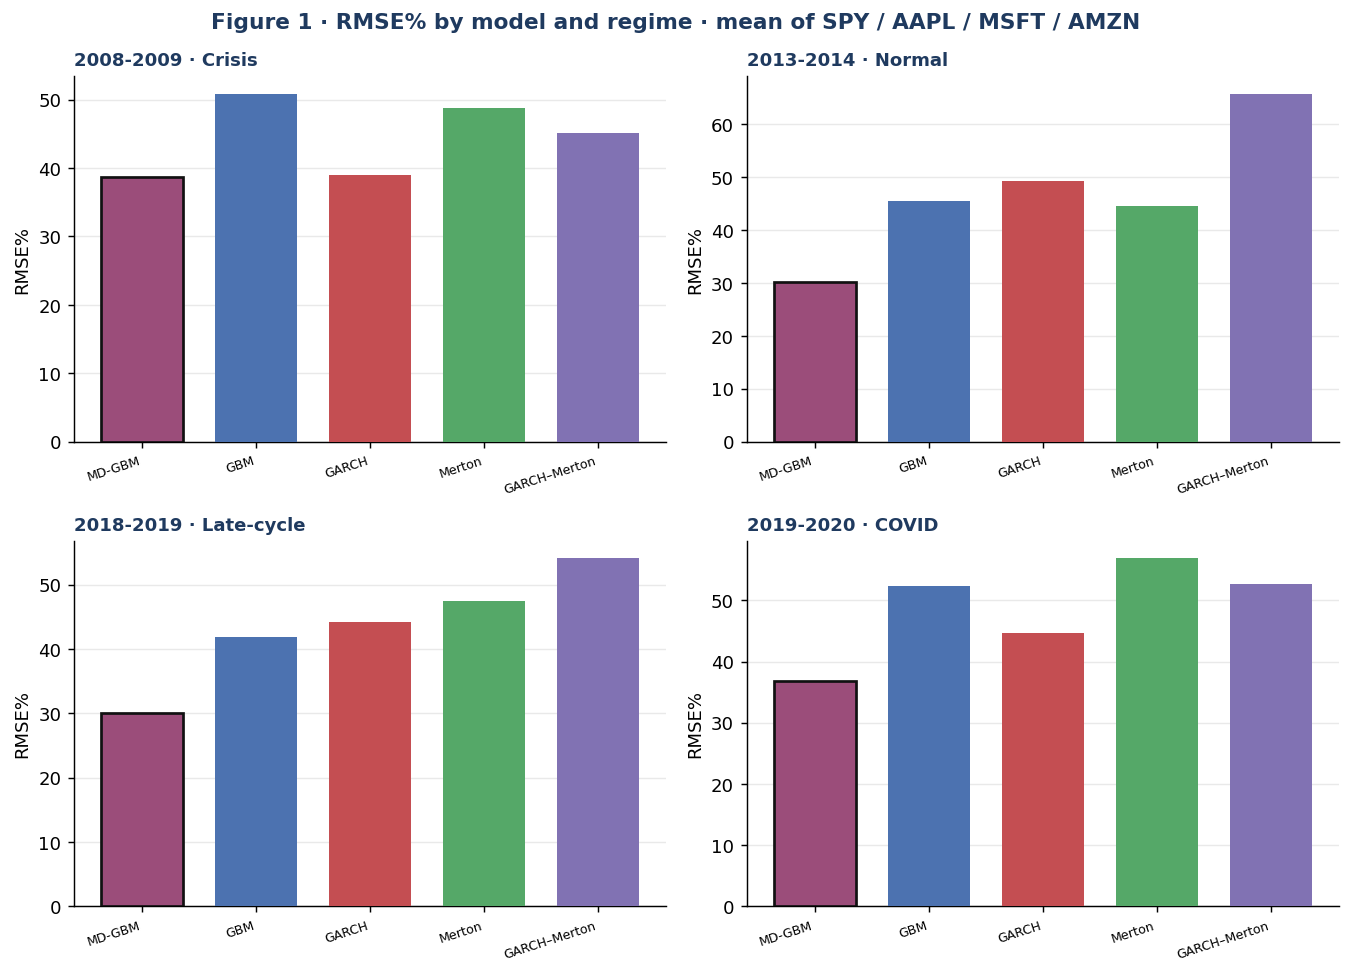

In [1]:
pass  # figure embedded from the same payload used for the PDF

### Figure 2 — RMSE% by company


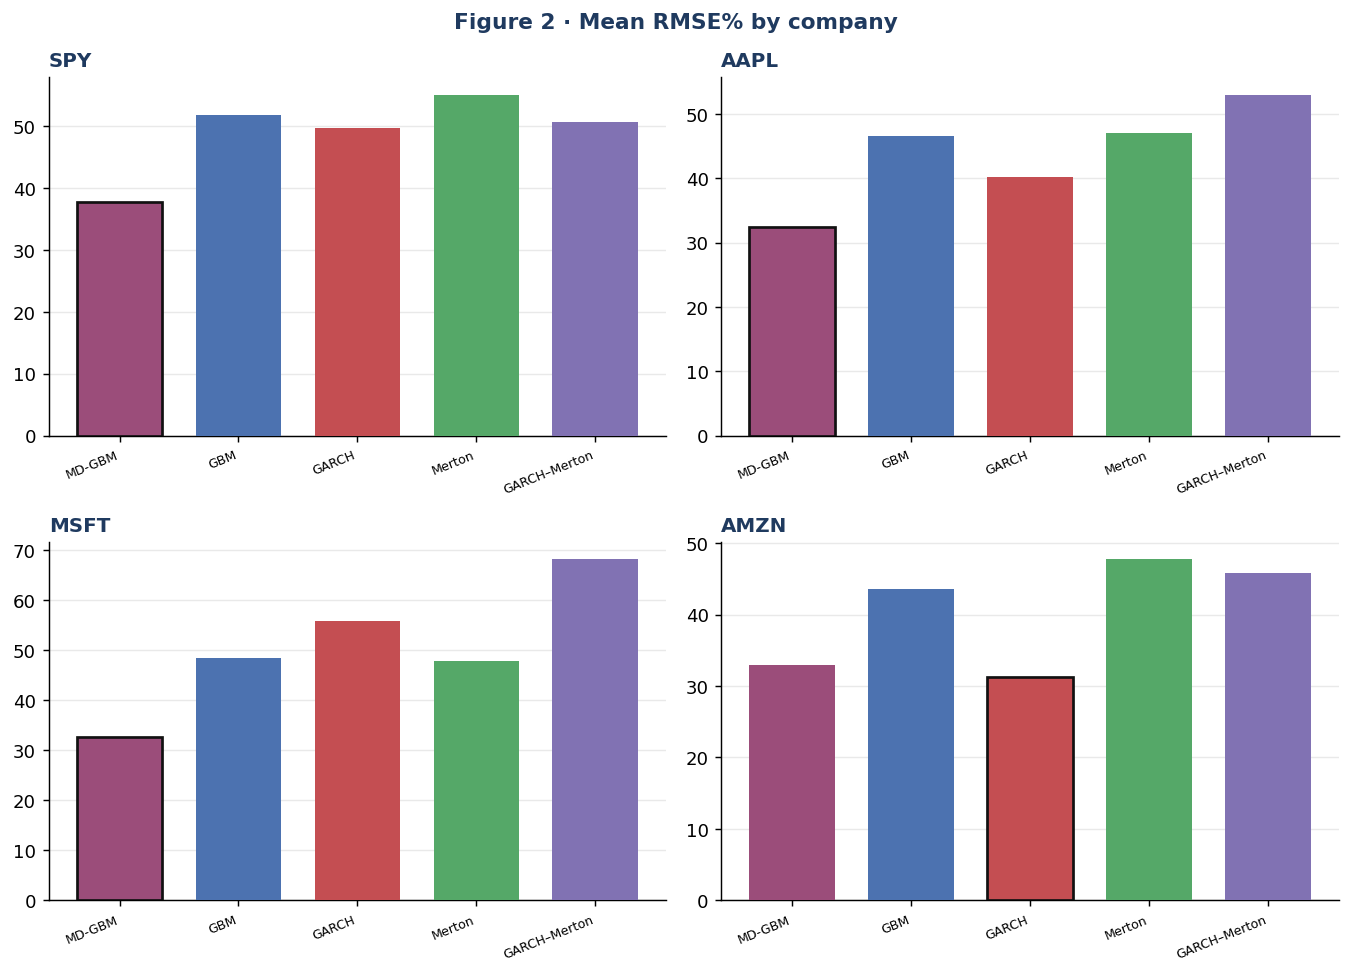

In [1]:
pass

### Figure 3 — Rank heatmap


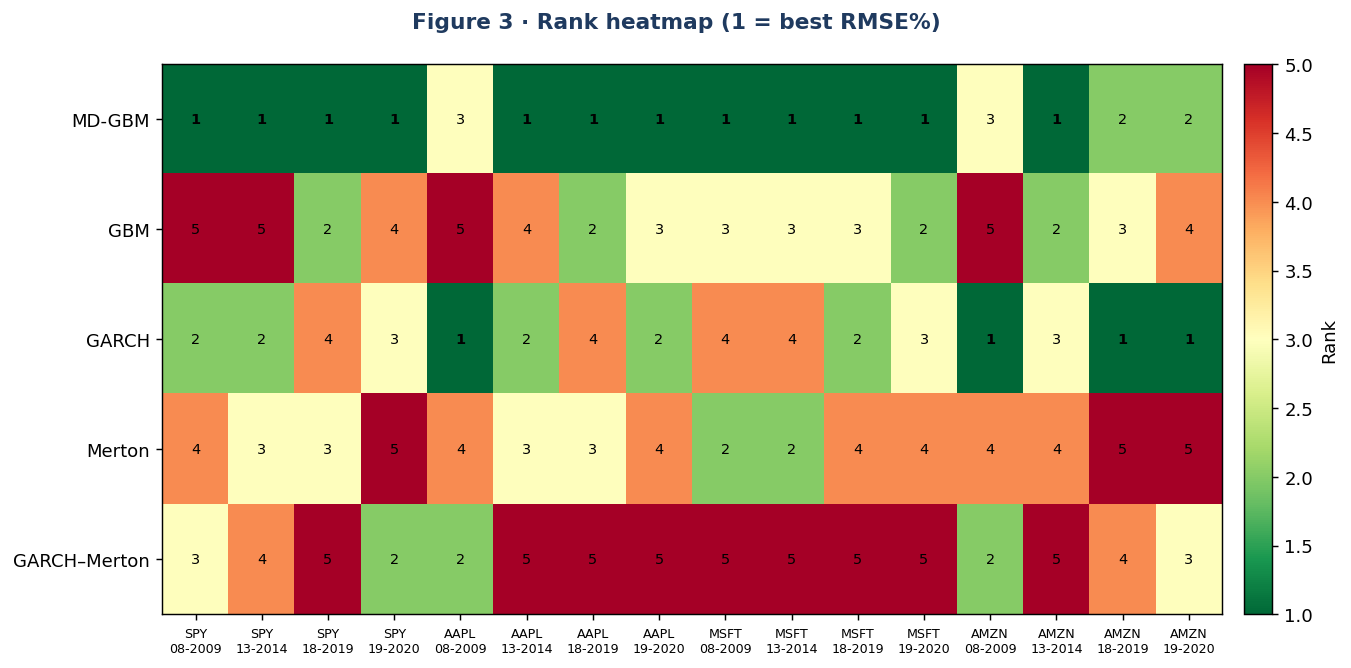

In [1]:
pass

## 5. Final analysis

- On mean percentage RMSE across the 16 company×regime cells, MD-GBM is the best overall model (mean RMSE% = 33.94; 12 of 16 cells).

- Second overall is GARCH (mean RMSE% = 44.24; 4 cells).

- The ranking is not stable. Best-in-cell models across the 16 tables: GARCH, MD-GBM.

- SPY: lowest mean RMSE% is MD-GBM (37.78); wins 4 of 4 regimes.

- AAPL: lowest mean RMSE% is MD-GBM (32.47); wins 3 of 4 regimes.

- MSFT: lowest mean RMSE% is MD-GBM (32.65); wins 4 of 4 regimes.

- AMZN: lowest mean RMSE% is GARCH (31.20); wins 3 of 4 regimes.

- 2008-2009 (Crisis): best mean RMSE% is MD-GBM (38.73).

- 2013-2014 (Normal): best mean RMSE% is MD-GBM (30.11).

- 2018-2019 (Late-cycle): best mean RMSE% is MD-GBM (30.08).

- 2019-2020 (COVID): best mean RMSE% is MD-GBM (36.85).

- No-jump models as a group have lower mean RMSE% (41.94) than the jump models in this report (51.93).

- For the overall winner (MD-GBM), crisis RMSE% is 38.73 vs 30.11 in the 2014 normal year — absolute pricing error is regime-dependent even when the ranking is not.

- These conclusions are conditional on the V3 filters, 1.5-year monthly calibration, Monday ATM sample, LSM with 10,000 paths, and American-call quotes only. They are not a statement about European options or other tenors.


## 6. Reproducibility

This grouped report is assembled from the frozen 10,000-path cells. No new calibration or LSM.

```python
import run_v3_1p5y_10k_monthly_empirical_study_groups as groups
payload = groups.load_group('return_based')
groups.write_group('return_based')
```

The original six-model files `V3_1p5y_monthly_empirical_study.pdf` / `.ipynb` are not rewritten.
Partial results remain in `V4-Models_result/results/empirical_study_1p5y_monthly_10000/partial/`.
Shared contracts are frozen in `shared_contracts.json`.
